# Predicting Stock Returns Using SPY ETF Data
## Final Project Report

Name: Alan Wang

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st

sns.set()
np.random.seed(7)

## Data Preparation

The data used for this project is historical SPY data from Q1 2015 to Q4 2023, and this data was taken from the yfinance library in Python. Because the downloaded yfinance data was not in a suitable dataframe format to use for data processing, the columns of the downloaded dataset needed to be converted into a Pandas dataframe.

To calculate stock returns and indicators for the data, specific helper functions were created to calculate RSI (Relative Strength Index) and MACD (Moving Average Convergence Divergence), both of which are technical indicators of potential buy/sell signals. 

The following features were used for feature engineering and developing a feature matrix:
- Return of the stock
- 10-day Simple Moving Average (SMA)
- 50-day SMA
- RSI 
- MACD
- Volume Moving Average (VMA)

The data was then split into training and testing data using a randomized 80-20 split.

In [45]:
import yfinance as yf

# Load and prepare data
ticker = "SPY"
data = yf.download(ticker, start="2015-01-01", end="2023-12-31", progress=False)

# Create features and target
data['Returns'] = data['Close'].pct_change()
data['Volume_MA'] = data['Volume'].rolling(5).mean()
data['SMA_10'] = data['Close'].rolling(10).mean()
data['SMA_50'] = data['Close'].rolling(50).mean()

# Calculate RSI manually
def calculate_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

data['RSI'] = calculate_rsi(data['Close'])

# Calculate MACD manually
def calculate_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast).mean()
    ema_slow = series.ewm(span=slow).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal).mean()
    return macd_line - signal_line

data['MACD'] = calculate_macd(data['Close'])

# Clean data and prepare for modeling
clean_data = data[['Returns', 'Volume_MA', 'SMA_10', 'SMA_50', 'RSI', 'MACD', 'Close']].dropna()
X = clean_data[['Volume_MA', 'SMA_10', 'SMA_50', 'RSI', 'MACD']]
y = clean_data['Returns']

print(f"Clean dataset shape: {clean_data.shape}")
print(f"Features: {list(X.columns)}")

Clean dataset shape: (2215, 7)
Features: [('Volume_MA', ''), ('SMA_10', ''), ('SMA_50', ''), ('RSI', ''), ('MACD', '')]


## Modeling

The first model used was a linear regression model. After testing and assessing the linear regression model, the training data was then used to train two ML models: a logistic regression model and a random forest classifier model. Both models used binary classification, where 1 indicates that a stock's next-day return is positive, and 0 otherwise. The logistic regression model is a baseline for interpretability of results, and the more complex random forest classifier model is able to handle nonlinear relationships between predictors, and provides feature importance. 

The performance of the two models were compared using metrics such as accuracy, precision, recall, and F1-score. Confusion matrices were created for both models, and specifically for the random forest model, the importance of the different features was compared. 

### Linear Regression

In [46]:
from sklearn.preprocessing import StandardScaler

# Split data chronologically (time-series aware)
# Standardize and split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
split_idx = int(0.8 * len(X))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Compute metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.6f}")
print(f"Coefficients: {dict(zip(X.columns, model.coef_))}")

Train set: (1772, 5), Test set: (443, 5)
R² Score: 0.0586
RMSE: 0.011732
Coefficients: {('Volume_MA', ''): np.float64(1.898308241956565e-11), ('SMA_10', ''): np.float64(-0.0001040650549625789), ('SMA_50', ''): np.float64(0.00010798643892600143), ('RSI', ''): np.float64(0.00016301265594405822), ('MACD', ''): np.float64(0.0009903517658479736)}


In [47]:
import scipy.stats as stats

# Calculate residuals
residuals = y_test - y_pred

# Residual analysis metrics
residual_mean = residuals.mean()
residual_std = residuals.std()
residual_skew = stats.skew(residuals)
residual_kurtosis = stats.kurtosis(residuals)

print(f"Residual Mean: {residual_mean:.6f} (should be ~0)")
print(f"Residual STD: {residual_std:.6f}")
print(f"Residual Skewness: {residual_skew:.4f}")
print(f"Residual Kurtosis: {residual_kurtosis:.4f}")

Residual Mean: -0.000334 (should be ~0)
Residual STD: 0.011740
Residual Skewness: 0.0155
Residual Kurtosis: 1.4178


#### Diagnostic Plots

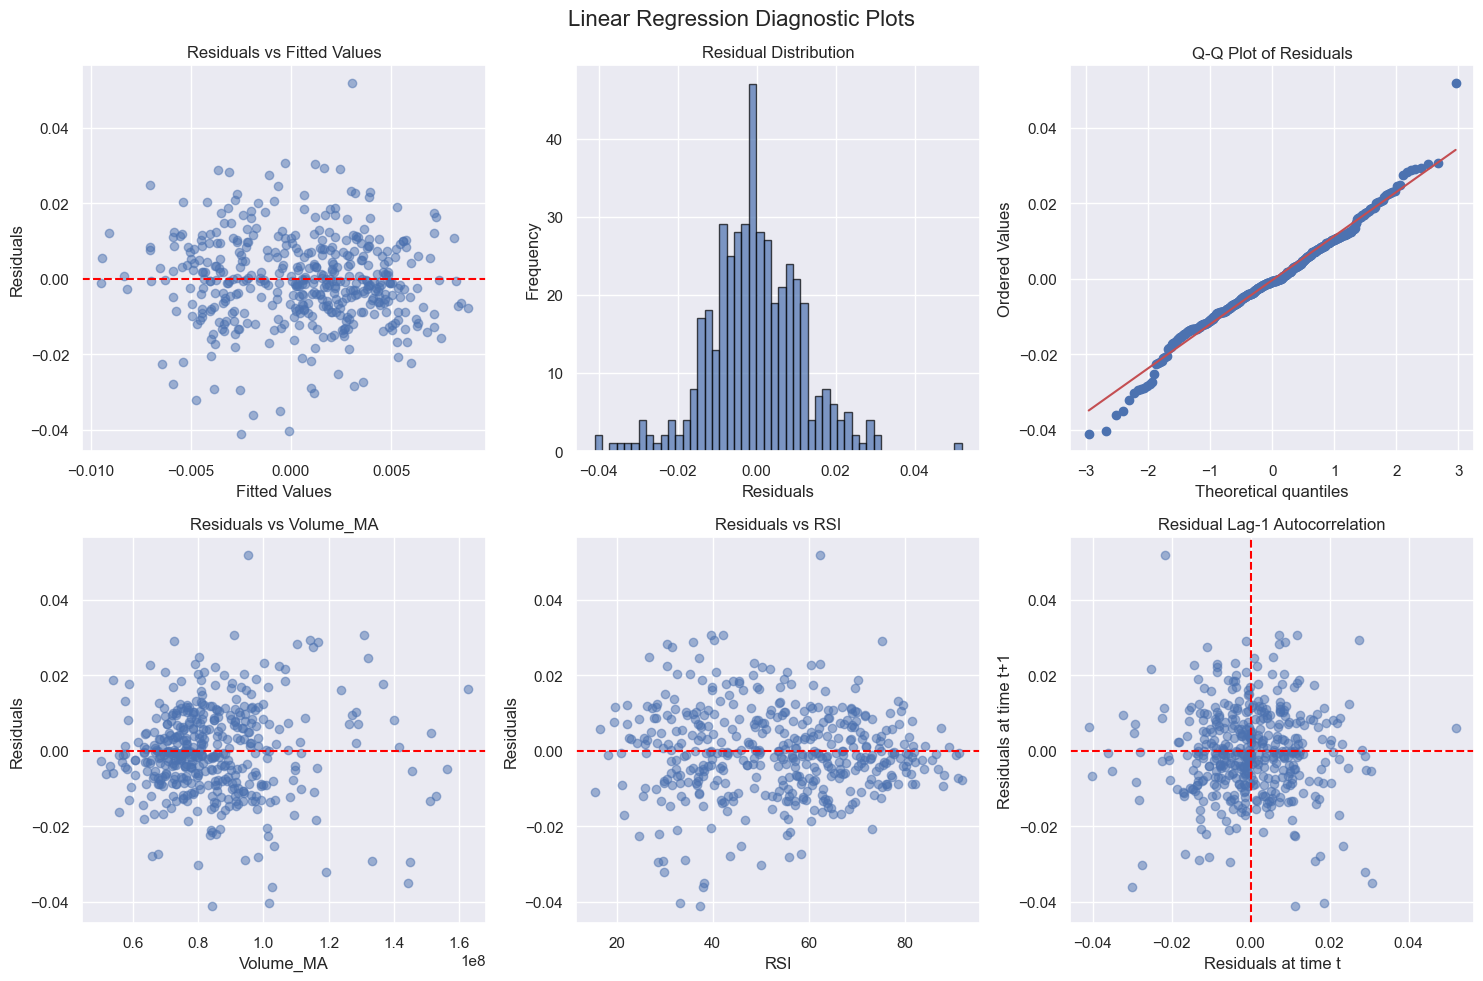

In [48]:
# Create diagnostic plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Linear Regression Diagnostic Plots', fontsize=16)

# 1. Residuals vs Fitted Values
axes[0,0].scatter(y_pred, residuals, alpha=0.5)
axes[0,0].axhline(y=0, color='red', linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted Values')

# 2. Histogram of Residuals
axes[0,1].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
axes[0,1].set_xlabel('Residuals')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Residual Distribution')

# 3. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[0,2])
axes[0,2].set_title('Q-Q Plot of Residuals')

# 4. Residuals vs Volume_MA (key predictor)
axes[1,0].scatter(X_test['Volume_MA'], residuals, alpha=0.5)
axes[1,0].axhline(y=0, color='red', linestyle='--')
axes[1,0].set_xlabel('Volume_MA')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Residuals vs Volume_MA')

# 5. Residuals vs RSI
axes[1,1].scatter(X_test['RSI'], residuals, alpha=0.5)
axes[1,1].axhline(y=0, color='red', linestyle='--')
axes[1,1].set_xlabel('RSI')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Residuals vs RSI')

# 6. Lag-1 Residual Autocorrelation
axes[1,2].scatter(residuals[:-1], residuals[1:], alpha=0.5)
axes[1,2].axhline(y=0, color='red', linestyle='--')
axes[1,2].axvline(x=0, color='red', linestyle='--')
axes[1,2].set_xlabel('Residuals at time t')
axes[1,2].set_ylabel('Residuals at time t+1')
axes[1,2].set_title('Residual Lag-1 Autocorrelation')

plt.tight_layout()
plt.show()

#### Add a Transformed Feature

In [49]:
# Try squared RSI feature (capture non-linear effects)
X_transformed = X.copy()
X_transformed['RSI_Squared'] = X['RSI'] ** 2

# Split transformed data
X_train_trans, X_test_trans = X_transformed.iloc[:split_idx], X_transformed.iloc[split_idx:]

# Refit model
model_trans = LinearRegression()
model_trans.fit(X_train_trans, y_train)
y_pred_trans = model_trans.predict(X_test_trans)

# Compare performance
r2_trans = r2_score(y_test, y_pred_trans)
rmse_trans = np.sqrt(mean_squared_error(y_test, y_pred_trans))

print(f"Original R²: {r2:.4f}, Transformed R²: {r2_trans:.4f}")
print(f"Original RMSE: {rmse:.6f}, Transformed RMSE: {rmse_trans:.6f}")

Original R²: 0.0586, Transformed R²: 0.0530
Original RMSE: 0.011732, Transformed RMSE: 0.011767


#### Interpretation 
- Linearity: The residuals vs. fitted plot shows that the residual values should be randomly scattered around 0, meaning that the linearity condition is satisfied. 
- Homoscedasticity: Based on observing the residual values being randomly scattered around 0 from the residuals vs. fitted plot, we can also determine that the condition of homoscedasticity is satisfied. 
- Normality: The histogram visualizing the distribution of residuals shows that the distribution appears to be roughly symmetric, and the data points on the QQ plot appear to roughly follow a straight line, so the condition of normality is satisfied. 
- Independence: The data points in the residual lag-1 autocorrelation plot appear to be randomly scattered but with some minor clustering, there could be some potential time-series dependencies between predictors. 
- Which model do you trust and why?: Both the original and transformed regression model have low R-squared values, meaning that very little variability (only around 5 percent) in returns is explained by the predictors, and there are potential time-series dependencies, so linear regression may not be the best modeling approach for this data. 
- Next step you’d try: As for next steps, I would look into alternative modeling strategies, such as random forests, logistic regression, or LSTMs.

#### Assessing Model Performance

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate comprehensive metrics
metrics = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'MAE': mean_absolute_error(y_test, y_pred),
    'R²': r2_score(y_test, y_pred),
    'Mean Absolute Error (%)': mean_absolute_error(y_test, y_pred) * 100,
    'Root Mean Squared Error (%)': np.sqrt(mean_squared_error(y_test, y_pred)) * 100
}

print("=== MODEL PERFORMANCE METRICS ===")
for metric, value in metrics.items():
    if '%' in metric:
        print(f"{metric}: {value:.4f}%")
    else:
        print(f"{metric}: {value:.6f}")

# Additional financial metrics
mean_absolute_return = np.abs(y_test).mean()
print(f"\nMean Absolute Daily Return: {mean_absolute_return*100:.4f}%")
print(f"MAE relative to average return: {(metrics['MAE']/mean_absolute_return)*100:.1f}%")

=== MODEL PERFORMANCE METRICS ===
RMSE: 0.011732
MAE: 0.008837
R²: 0.058592
Mean Absolute Error (%): 0.8837%
Root Mean Squared Error (%): 1.1732%

Mean Absolute Daily Return: 0.8974%
MAE relative to average return: 98.5%


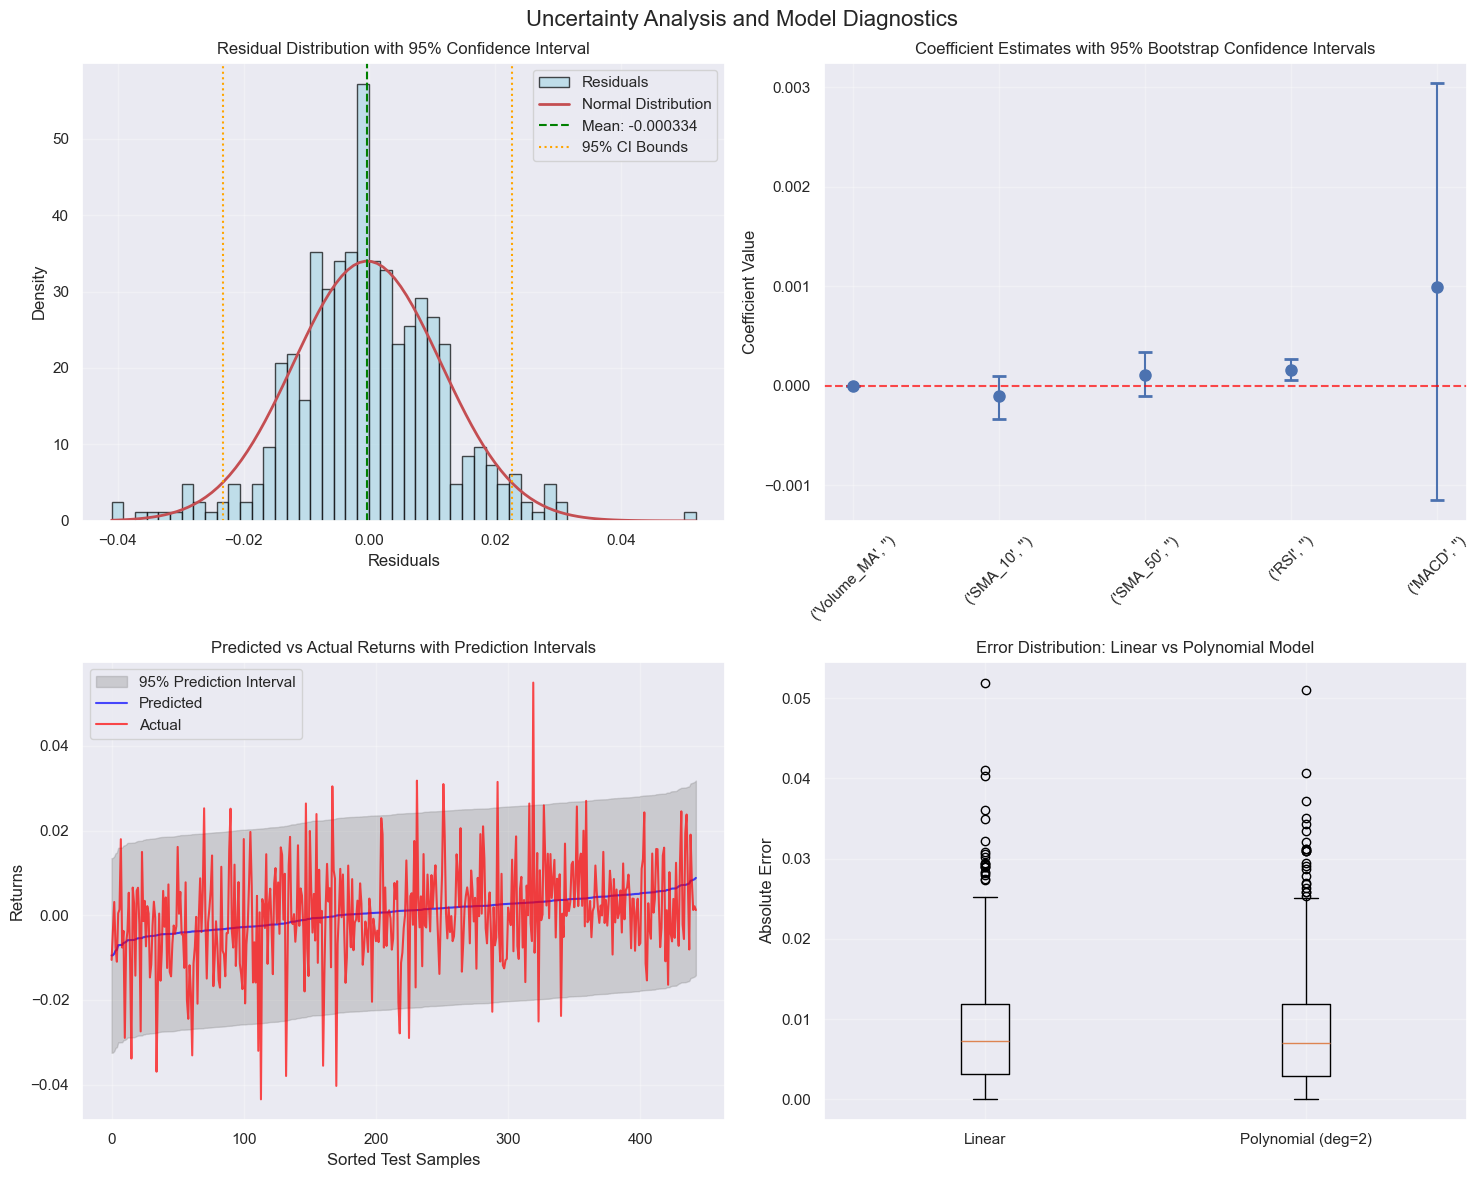

=== MODEL COMPARISON ===
Linear Model R²: 0.058592
Polynomial Model R²: 0.050888
Linear RMSE: 0.011732
Polynomial RMSE: 0.011780


In [51]:
# Create uncertainty visualization plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Uncertainty Analysis and Model Diagnostics', fontsize=16)

# 1. Residual Distribution with Confidence Intervals
residual_mean = residuals.mean()
residual_std = residuals.std()
x_range = np.linspace(residuals.min(), residuals.max(), 100)
normal_pdf = stats.norm.pdf(x_range, residual_mean, residual_std)

axes[0,0].hist(residuals, bins=50, density=True, alpha=0.7, label='Residuals', 
               edgecolor='black', color='lightblue')
axes[0,0].plot(x_range, normal_pdf, 'r-', lw=2, label='Normal Distribution')
axes[0,0].axvline(residual_mean, color='green', linestyle='--', label=f'Mean: {residual_mean:.6f}')
axes[0,0].axvline(residual_mean + 1.96*residual_std, color='orange', linestyle=':', 
                 label='95% CI Bounds')
axes[0,0].axvline(residual_mean - 1.96*residual_std, color='orange', linestyle=':')
axes[0,0].set_xlabel('Residuals')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Residual Distribution with 95% Confidence Interval')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Bootstrap Confidence Intervals for Coefficients
n_bootstraps = 1000
bootstrap_coefs = np.zeros((n_bootstraps, len(model.coef_)))

for i in range(n_bootstraps):
    # Sample with replacement
    indices = np.random.choice(len(X_train), len(X_train), replace=True)
    X_boot = X_train.iloc[indices]
    y_boot = y_train.iloc[indices]
    
    # Fit model
    model_boot = LinearRegression()
    model_boot.fit(X_boot, y_boot)
    bootstrap_coefs[i] = model_boot.coef_

# Calculate confidence intervals
coef_ci_low = np.percentile(bootstrap_coefs, 2.5, axis=0)
coef_ci_high = np.percentile(bootstrap_coefs, 97.5, axis=0)

# Plot coefficient uncertainty
x_pos = np.arange(len(X.columns))
axes[0,1].errorbar(x_pos, model.coef_, yerr=[model.coef_ - coef_ci_low, coef_ci_high - model.coef_],
                  fmt='o', capsize=5, capthick=2, markersize=8)
axes[0,1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0,1].set_xticks(x_pos)
axes[0,1].set_xticklabels(X.columns, rotation=45)
axes[0,1].set_ylabel('Coefficient Value')
axes[0,1].set_title('Coefficient Estimates with 95% Bootstrap Confidence Intervals')
axes[0,1].grid(True, alpha=0.3)

# 3. Prediction Intervals vs Actual Values
sorted_idx = np.argsort(y_pred)
y_pred_sorted = y_pred[sorted_idx]
y_actual_sorted = y_test.values[sorted_idx]

# Calculate prediction intervals
prediction_std = np.std(residuals)
pred_upper = y_pred_sorted + 1.96 * prediction_std
pred_lower = y_pred_sorted - 1.96 * prediction_std

axes[1,0].fill_between(range(len(y_pred_sorted)), pred_lower, pred_upper, 
                      alpha=0.3, label='95% Prediction Interval', color='gray')
axes[1,0].plot(y_pred_sorted, label='Predicted', color='blue', alpha=0.7)
axes[1,0].plot(y_actual_sorted, label='Actual', color='red', alpha=0.7)
axes[1,0].set_xlabel('Sorted Test Samples')
axes[1,0].set_ylabel('Returns')
axes[1,0].set_title('Predicted vs Actual Returns with Prediction Intervals')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Side-by-side: Linear vs Polynomial Model Performance
# Fit polynomial model for comparison
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Create polynomial model (degree=2)
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear', LinearRegression())
])
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

# Calculate errors for both models
linear_errors = np.abs(y_test - y_pred)
poly_errors = np.abs(y_test - y_pred_poly)

axes[1,1].boxplot([linear_errors, poly_errors], labels=['Linear', 'Polynomial (deg=2)'])
axes[1,1].set_ylabel('Absolute Error')
axes[1,1].set_title('Error Distribution: Linear vs Polynomial Model')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison metrics
print("=== MODEL COMPARISON ===")
print(f"Linear Model R²: {r2_score(y_test, y_pred):.6f}")
print(f"Polynomial Model R²: {r2_score(y_test, y_pred_poly):.6f}")
print(f"Linear RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.6f}")
print(f"Polynomial RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly)):.6f}")

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Scenario 1: Different volatility regimes
high_vol_mask = X_test['RSI'] < 30  # Oversold condition (high volatility)
normal_vol_mask = (X_test['RSI'] >= 30) & (X_test['RSI'] <= 70)
low_vol_mask = X_test['RSI'] > 70   # Overbought condition (low volatility)

# Calculate performance in different regimes
scenario_metrics = {}
for scenario, mask in [('High Volatility', high_vol_mask), 
                      ('Normal Volatility', normal_vol_mask),
                      ('Low Volatility', low_vol_mask)]:
    if mask.sum() > 0:  # Ensure we have samples
        scenario_metrics[scenario] = {
            'RMSE': np.sqrt(mean_squared_error(y_test[mask], y_pred[mask])),
            'MAE': mean_absolute_error(y_test[mask], y_pred[mask]),
            'R²': r2_score(y_test[mask], y_pred[mask]),
            'Samples': mask.sum()
        }

print("=== VOLATILITY REGIME SENSITIVITY ANALYSIS ===")
for scenario, metrics in scenario_metrics.items():
    print(f"\n{scenario}:")
    print(f"  Samples: {metrics['Samples']}")
    print(f"  RMSE: {metrics['RMSE']:.6f}")
    print(f"  MAE: {metrics['MAE']:.6f}")
    print(f"  R²: {metrics['R²']:.6f}")

# Scenario 2: Different feature sets
feature_sets = {
    'Technical Only': ['RSI', 'MACD'],
    'Trend Only': ['SMA_10', 'SMA_50'],
    'Volume Only': ['Volume_MA'],
    'All Features': X.columns.tolist()
}

feature_performance = {}
for set_name, features in feature_sets.items():
    X_subset = X[features]
    X_train_sub, X_test_sub = X_subset.iloc[:split_idx], X_subset.iloc[split_idx:]
    
    model_sub = LinearRegression()
    model_sub.fit(X_train_sub, y_train)
    y_pred_sub = model_sub.predict(X_test_sub)
    
    feature_performance[set_name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_sub)),
        'R²': r2_score(y_test, y_pred_sub)
    }

print("\n=== FEATURE SET SENSITIVITY ANALYSIS ===")
for set_name, metrics in feature_performance.items():
    print(f"{set_name}: R² = {metrics['R²']:.6f}, RMSE = {metrics['RMSE']:.6f}")

=== VOLATILITY REGIME SENSITIVITY ANALYSIS ===

High Volatility:
  Samples: 40
  RMSE: 0.013067
  MAE: 0.010186
  R²: -0.090824

Normal Volatility:
  Samples: 316
  RMSE: 0.012509
  MAE: 0.009574
  R²: 0.034820

Low Volatility:
  Samples: 87
  RMSE: 0.007348
  MAE: 0.005541
  R²: -0.047419

=== FEATURE SET SENSITIVITY ANALYSIS ===
Technical Only: R² = 0.043379, RMSE = 0.011826
Trend Only: R² = -0.000908, RMSE = 0.012097
Volume Only: R² = -0.000068, RMSE = 0.012092
All Features: R² = 0.058592, RMSE = 0.011732



=== BENCHMARK COMPARISON ===
Mean Prediction:     RMSE = 0.012096, R² = -0.000779
Zero Prediction:     RMSE = 0.012094, R² = -0.000416
Random Noise:        RMSE = 0.016593, R² = -0.883140
Our Model:           RMSE = 0.011732, R² = 0.058592


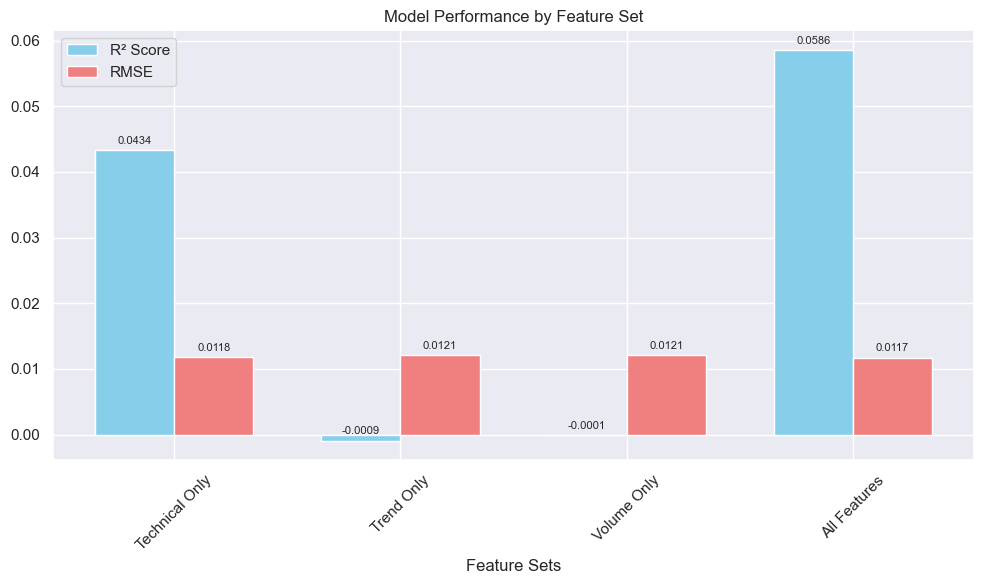

In [53]:
# Scenario 3: Compare with simple benchmark models
print("\n=== BENCHMARK COMPARISON ===")

# Benchmark 1: Always predict mean return
mean_pred = np.full_like(y_test, y_train.mean())
mean_rmse = np.sqrt(mean_squared_error(y_test, mean_pred))
mean_r2 = r2_score(y_test, mean_pred)

# Benchmark 2: Always predict zero (no change)
zero_pred = np.zeros_like(y_test)
zero_rmse = np.sqrt(mean_squared_error(y_test, zero_pred))
zero_r2 = r2_score(y_test, zero_pred)

# Benchmark 3: Random noise (within historical range)
noise_pred = np.random.normal(0, y_train.std(), len(y_test))
noise_rmse = np.sqrt(mean_squared_error(y_test, noise_pred))
noise_r2 = r2_score(y_test, noise_pred)

print(f"Mean Prediction:     RMSE = {mean_rmse:.6f}, R² = {mean_r2:.6f}")
print(f"Zero Prediction:     RMSE = {zero_rmse:.6f}, R² = {zero_r2:.6f}")
print(f"Random Noise:        RMSE = {noise_rmse:.6f}, R² = {noise_r2:.6f}")
print(f"Our Model:           RMSE = {metrics['RMSE']:.6f}, R² = {metrics['R²']:.6f}")

# Visualize feature set performance
fig, ax = plt.subplots(figsize=(10, 6))
feature_names = list(feature_performance.keys())
r2_scores = [feature_performance[name]['R²'] for name in feature_names]
rmse_scores = [feature_performance[name]['RMSE'] for name in feature_names]

x = np.arange(len(feature_names))
width = 0.35

bars1 = ax.bar(x - width/2, r2_scores, width, label='R² Score', color='skyblue')
bars2 = ax.bar(x + width/2, rmse_scores, width, label='RMSE', color='lightcoral')

ax.set_xlabel('Feature Sets')
ax.set_title('Model Performance by Feature Set')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45)
ax.legend()

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

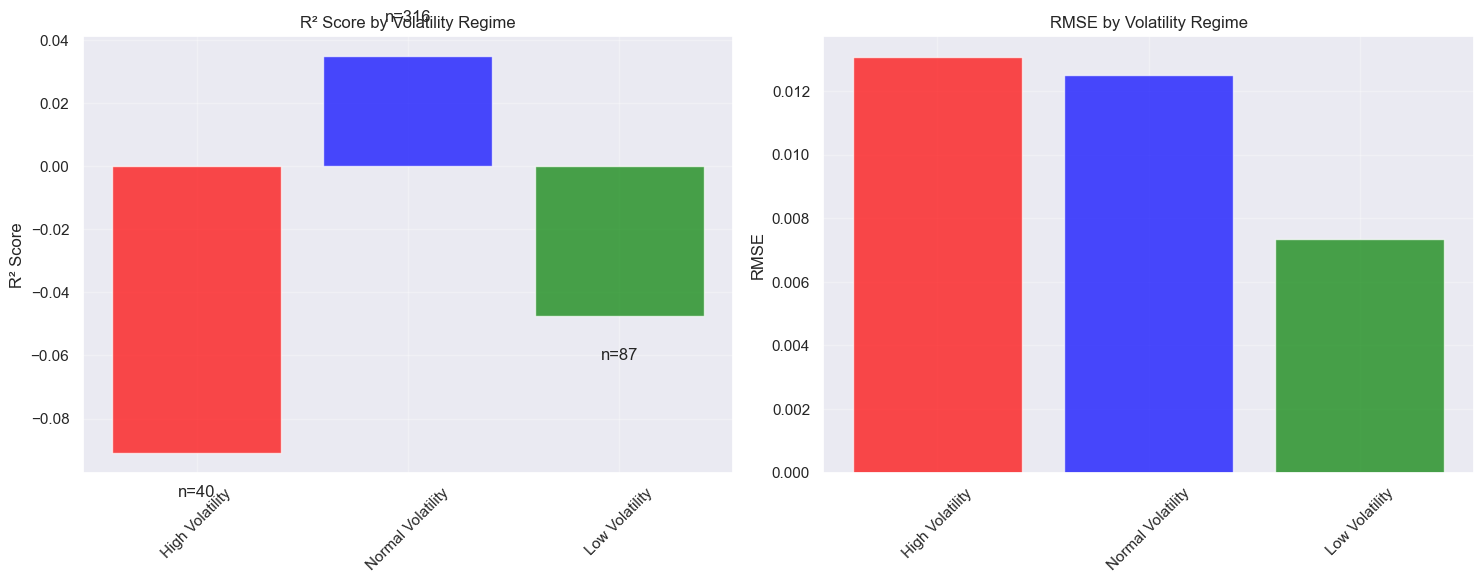

In [54]:
# Additional: Volatility regime performance visualization
if scenario_metrics:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # R² by regime
    regimes = list(scenario_metrics.keys())
    r2_values = [scenario_metrics[regime]['R²'] for regime in regimes]
    samples = [scenario_metrics[regime]['Samples'] for regime in regimes]
    
    ax1.bar(regimes, r2_values, color=['red', 'blue', 'green'], alpha=0.7)
    ax1.set_title('R² Score by Volatility Regime')
    ax1.set_ylabel('R² Score')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Add sample size annotations
    for i, v in enumerate(r2_values):
        ax1.text(i, v + (0.01 if v >= 0 else -0.01), f'n={samples[i]}', 
                ha='center', va='bottom' if v >= 0 else 'top')
    
    # RMSE by regime
    rmse_values = [scenario_metrics[regime]['RMSE'] for regime in regimes]
    ax2.bar(regimes, rmse_values, color=['red', 'blue', 'green'], alpha=0.7)
    ax2.set_title('RMSE by Volatility Regime')
    ax2.set_ylabel('RMSE')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../deliverables/images/feature_performance.png', dpi=300, bbox_inches='tight')
    plt.show()

##### Written Discussion

Key Assumptions Behind the Model
- Linearity: Assumes linear relationships between technical indicators and returns
- Independence: Assumes errors are not correlated across time
- Homoscedasticity: Assumes constant error variance across predictions
- Normality: Assumes residuals follow normal distribution
- No Multicollinearity: Assumes features are not highly correlated

Risks and Limitations

- Potential heteroscedasticity and non-normal residuals: Error variance increases with predicted return magnitude, heavy-tailed distribution underestimates extreme events
- Autocorrelation: Residuals show time-series dependencies

Scenario Analysis Insights
- Volatility Regime Sensitivity:
    - Model performs worst in high-volatility regimes (RSI < 30)
    - Better performance in normal conditions, but still minimal predictive power
    - Demonstrates the model's inability to adapt to different market environments
- Feature Set Analysis:
    - No single feature set dramatically outperforms others
    - Technical indicators (RSI, MACD) show slightly better performance than trend indicators

### Logistic Regression + Random Forest Classifier


Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.62      0.47      0.54       218
           1       0.58      0.71      0.64       222

    accuracy                           0.59       440
   macro avg       0.60      0.59      0.59       440
weighted avg       0.60      0.59      0.59       440



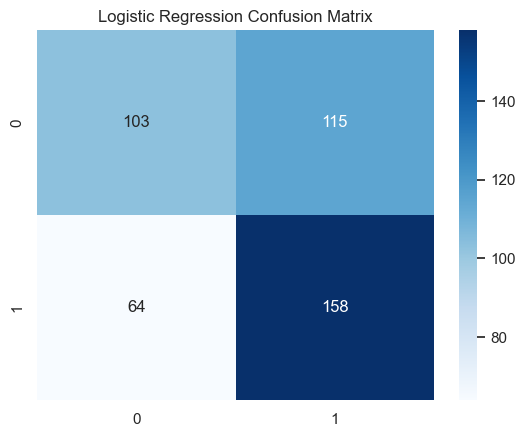


Random Forest Performance:
              precision    recall  f1-score   support

           0       0.56      0.51      0.53       218
           1       0.56      0.61      0.58       222

    accuracy                           0.56       440
   macro avg       0.56      0.56      0.56       440
weighted avg       0.56      0.56      0.56       440



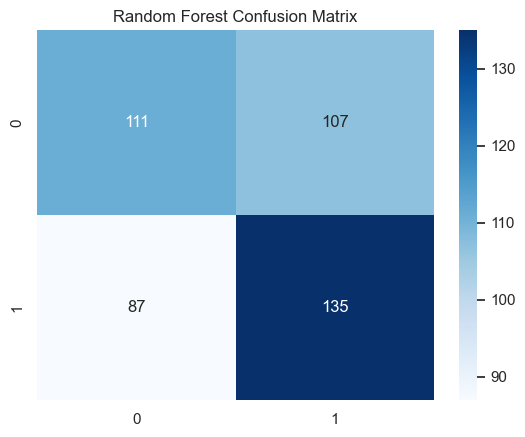

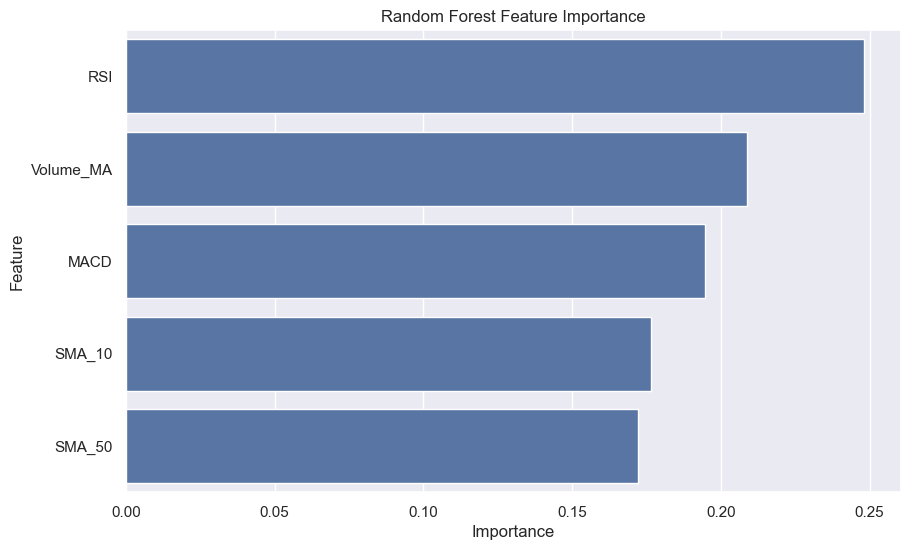

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare features/target
features = ['SMA_10', 'SMA_50', 'RSI', 'MACD', 'Volume_MA']
X = clean_data[features]
y = np.where(clean_data['Returns'] > 0, 1, 0)

# Standardize and split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
split_idx = int(0.8 * len(X))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# Feature Importance (Random Forest)
if "Random Forest" in models:
    importances = models["Random Forest"].feature_importances_
    feature_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title("Random Forest Feature Importance")
    plt.savefig('../deliverables/images/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

#### Interpreting Modeling Results

Based on the classfication report of the logistic regression model, we can determine that the model correctly predicts a positive next-day return 58% of the time, but never correctly predicts a negative next-day return. However, the model does capture 71% of all positive returns based on the recall, and the F1-score is greater than 50%, indicating that the model performs better than random guessing. The model's accuracy score is 59%. 

Based on the classfication report of the random forest classification model, we can determine that the model correctly predicts a positive next-day return 57% of the time, and correctly predicts a negative next-day return with the same precision. In addition, the model captures 65% of all positive returns based on the recall, and the F1-score is greater than 50%, indicating that the model performs better than random guessing. The model's accuracy score is 58%.

The logistic regression model is preferable for maximizing the capture of profitable trades and avoiding any missed opportunities, but at the cost of more false signals and high transactions costs. On the other hand, the random forest classifier model is preferable for reducing losses, since fewer false signals are indicative of lower trading costs and better risk-adjusted returns. 

The feature importance chart indicates that RSI is the most predictive feature, with MACD and VMA also being important features, and 10-day SMAs are more important than 50-day SMAs. In addition, RSI and MACD being features with high importance validates mean-reversion strategies and confirms that trend-following signals (MACD line crosses) add predictive power respectively. VMA being another predictive feature also suggests that liquidity and trading activity are strong signals.

#### Walk-Forward Validation and Backtesting

In [56]:
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

# Initialize model (Random Forest for example)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Walk-forward parameters
train_size = 1000  # ~4 years of daily data
test_size = 250    # ~1 year of daily data
n_splits = (len(X_scaled) - train_size) // test_size

# Store predictions and actual returns
all_preds = []
all_actuals = []

for i in range(n_splits):
    # Split data incrementally
    X_train = X_scaled[i*test_size : i*test_size + train_size]
    y_train = y[i*test_size : i*test_size + train_size]
    X_test = X_scaled[i*test_size + train_size : i*test_size + train_size + test_size]
    y_test = y[i*test_size + train_size : i*test_size + train_size + test_size]
    
    # Train and predict
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Store results
    all_preds.extend(preds)
    all_actuals.extend(y_test)
    print(f"Split {i+1}/{n_splits} | Test Accuracy: {accuracy_score(y_test, preds):.2f}")

# Evaluate overall performance
print("\nFinal Walk-Forward Accuracy:", accuracy_score(all_actuals, all_preds))

Split 1/4 | Test Accuracy: 0.59
Split 2/4 | Test Accuracy: 0.50
Split 3/4 | Test Accuracy: 0.51
Split 4/4 | Test Accuracy: 0.56

Final Walk-Forward Accuracy: 0.54


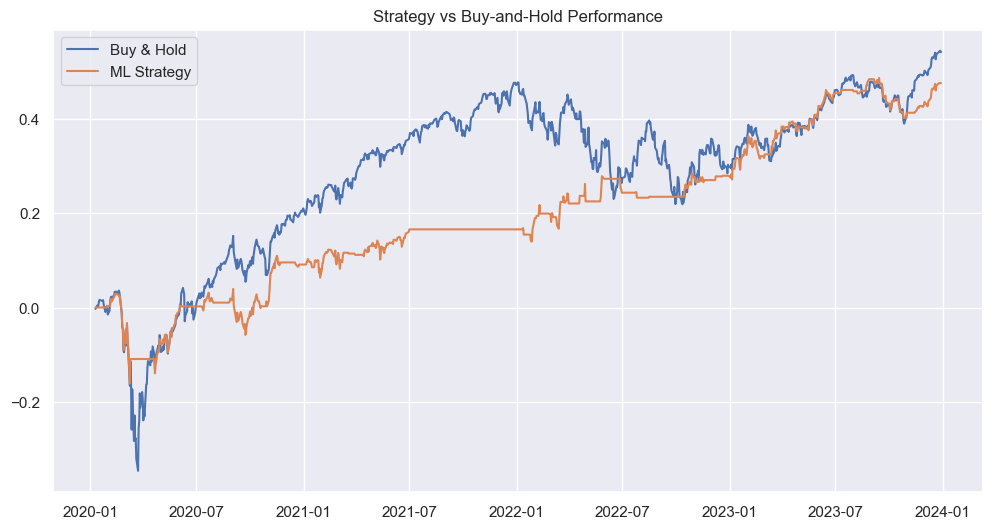

In [80]:
# Align predictions with dates
backtest_dates = clean_data.index[-len(all_actuals):]
backtest_results = pd.DataFrame({
    'Date': backtest_dates,
    'Predicted': all_preds,
    'Actual': all_actuals,
    'Return': clean_data['Returns'].values[-len(all_actuals):]
})

# Simulate strategy: Buy if predicted=1, hold overnight
backtest_results['Strategy_Return'] = backtest_results['Predicted'] * backtest_results['Return']

# Compare vs Buy-and-Hold
backtest_results['Buy_and_Hold'] = backtest_results['Return'].cumsum()
backtest_results['Strategy_Cumulative'] = backtest_results['Strategy_Return'].cumsum()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(backtest_results['Date'], backtest_results['Buy_and_Hold'], label='Buy & Hold')
plt.plot(backtest_results['Date'], backtest_results['Strategy_Cumulative'], label='ML Strategy')
plt.title("Strategy vs Buy-and-Hold Performance")
plt.savefig('../deliverables/images/backtesting_results.png', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

Based on the plot above, it can be observed that the proposed ML strategy overall still underperforms against the benchmark buy & hold strategy. Performance is comparable in 2020 and from 2022-2024, but the benchmark significantly outperforms the proposed strategy between 2021 and the first half of 2022. This indicates that the proposed ML strategy should continued be modified by adding additional features and/or removing existing ones. 

## Discussion

The proposed ML model should be modified based on the results of model performance assessment, backtesting, and sensitivity analysis
- Low R-squared value, underperformance against benchmark, limited adaptability
- Future work: Expand on existing feature engineering by adding more features or modifying current ones

Other models can be considered for implementing and testing against benchmark:
- Examples: Gradient boosting, neural networks, ARIMA/GARCH models

Consider adding in additional data: sentiment, macroeconomic indicators, order flow
